In [208]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from keras.models import Sequential
from keras.layers import LSTM, RepeatVector, TimeDistributed, Dense
from sklearn.preprocessing import MinMaxScaler
import matplotlib.dates as mdates
from itertools import groupby
from operator import itemgetter
from statsmodels.tsa.arima.model import ARIMA
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


In [60]:
### LOADING FILES 

CB9401df = pd.read_csv("CBOE Volatility Index Historical Data 1994-2001.csv")
CB1525df  = pd.read_csv("CBOE Volatility Index Historical Data 2015-2025.csv")

SP9401df  = pd.read_csv("S&P 500 Historical Data 1994-2001.csv")
SP1525df  = pd.read_csv("S&P 500 Historical Data 2015-2025.csv")

NY9401df  = pd.read_csv("NYSE 1994-2001.csv")
NY1525df  = pd.read_csv("NYSE 2015-2025.csv")

NQ9401df  = pd.read_csv("NASDAQ Composite 1994-2001.csv")
NQ1525df  = pd.read_csv("NASDAQ Composite 2015-2025.csv")

MAIPOdf = pd.read_excel('Monthly Number of IPOs and the AVG first-day Return.xlsx')
VCIPOdf = pd.read_excel('List of Venture Capital Backed IPOs.xlsx')

### NOT USING RN

# MTdf = pd.read_excel('money-left-on-the-table.xlsx')
# LNPAAIdf  = pd.read_csv("LeidenNetworkPATHCharacteristicsAIGlobal.csv")
# LNDENAIdf  = pd.read_csv("LeidenNetworkDENSITYCharacteristicsAIGlobal.csv")
# LNBURAIdf  = pd.read_csv("LeidenNetworkBURSTDATACharacteristicsAIGlobal.csv")

# LNPAGNdf  = pd.read_csv("LeidenNetworkPATHCharacteristicsGN.csv")
# LNDENGNdf  = pd.read_csv("LeidenNetworkDENSITYCharacteristicsGN.csv")
# LNBURGNdf  = pd.read_csv("LeidenNetworkBURSTDATACharacteristicsGN.csv")



In [61]:
## MODIFY THE VC BACKED IPOs TO MAINTAIN MONTHY TIME AXIS

VCIPOdf["offer date"] = pd.to_datetime(VCIPOdf["offer date"].astype(str), format = "%Y%m%d")

VCIPOdf = VCIPOdf[VCIPOdf["VC"] == 1]

VCIPOdf["offer date"] = pd.to_datetime(VCIPOdf["offer date"])

VCIPOdf = (VCIPOdf.set_index("offer date").resample("M").size().reset_index(name = "VC IPOS"))

/var/folders/jj/g6ntzrwd1lsfbtjw18m8nwd00000gn/T/ipykernel_64729/1439250576.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  VCIPOdf = (VCIPOdf.set_index("offer date").resample("M").size().reset_index(name = "VC IPOS"))


In [63]:
## MODIFY THE Monthly Number of IPOs and the AVG first-day Return

MAIPOdf["date"] = (MAIPOdf["Year"] >= 90) * (1900 + MAIPOdf["Year"]) + (MAIPOdf["Year"] < 90) * (2000 + MAIPOdf["Year"])

MAIPOdf["Date"] = pd.to_datetime(pd.DataFrame({
    "year" : MAIPOdf["date"],
    "month" : MAIPOdf["Month"],
    "day" : 1
}))

In [64]:
MAIPOdf = MAIPOdf.drop(columns=['Month', 'Year', 'date'])
MAIPOdf

,average first-day % return,percentage priced above the midpoint of the original file price range,Date
0,11.2,76,1993-01-01
1,18.3,67,1993-02-01
2,12.9,60,1993-03-01
3,14.2,35,1993-04-01
4,9.5,58,1993-05-01
...,...,...,...
379,31.8,0,2024-08-01
380,6.7,29,2024-09-01
381,11.1,56,2024-10-01
382,0.3,0,2024-11-01


In [69]:
### ????

MAIPOdf["Date"] = MAIPOdf["Date"].dt.strftime("%m/%d/%Y")
 
VCIPOdf["offer date"] = pd.to_datetime(VCIPOdf["offer date"])

VCIPOdf["offer date"] = VCIPOdf ["offer date"].dt.to_period("M").dt.to_timestamp()

VCIPOdf["offer date"] = VCIPOdf["offer date"].dt.strftime("%m/%d/%Y")
VCIPOdf



,offer date,VC IPOS
0,01/01/1993,8
1,02/01/1993,15
2,03/01/1993,24
3,04/01/1993,8
4,05/01/1993,10
...,...,...
380,09/01/2024,6
381,10/01/2024,8
382,11/01/2024,3
383,12/01/2024,4


In [85]:


NQ1525df['Date'] = pd.to_datetime(NQ1525df['Date']) 
NQ1525df = NQ1525df[NQ1525df['Date'] != pd.to_datetime('04/01/2025')]
NQ1525df

CB1525df['Date'] = pd.to_datetime(CB1525df['Date']) 
CB1525df = CB1525df[CB1525df['Date'] != pd.to_datetime('04/01/2025')]
CB1525df

SP1525df['Date'] = pd.to_datetime(SP1525df['Date']) 
SP1525df = SP1525df[SP1525df['Date'] != pd.to_datetime('04/01/2025')]
SP1525df


,Date,Price,Open,High,Low,Vol.,Change %
1,2025-03-01,"5,611.85","5,968.33","5,986.09","5,488.73",NaN,-5.75%
2,2025-02-01,"5,954.50","5,969.65","6,147.43","5,837.66",NaN,-1.42%
3,2025-01-01,"6,040.53","5,903.26","6,128.18","5,773.31",NaN,2.70%
4,2024-12-01,"5,881.63","6,040.11","6,099.97","5,832.30",NaN,-2.50%
5,2024-11-01,"6,032.38","5,723.22","6,044.17","5,696.51",NaN,5.73%
...,...,...,...,...,...,...,...
118,2015-06-01,"2,063.11","2,108.64","2,129.87","2,056.32",NaN,-2.10%
119,2015-05-01,"2,107.39","2,087.38","2,134.72","2,067.93",NaN,1.05%
120,2015-04-01,"2,085.51","2,067.63","2,125.92","2,048.38",NaN,0.85%
121,2015-03-01,"2,067.89","2,105.23","2,117.52","2,039.69",NaN,-1.74%


In [105]:
CB1525df["Date"] = CB1525df["Date"].dt.strftime("%m/%d/%Y")
CB1525df

SP1525df["Date"] = SP1525df["Date"].dt.strftime("%m/%d/%Y")
SP1525df

NQ1525df["Date"] = NQ1525df["Date"].dt.strftime("%m/%d/%Y")
NQ1525df


,Date,Price,Open,High,Low,Vol.,Change %
1,03/01/2025,"17,299.29","18,923.36","18,992.30","16,854.37",30.70B,-8.21%
2,02/01/2025,"18,847.28","19,215.38","20,110.12","18,372.99",26.42B,-3.97%
3,01/01/2025,"19,627.44","19,403.90","20,118.61","18,831.91",27.48B,1.64%
4,12/01/2024,"19,310.79","19,255.43","20,204.58","19,168.38",29.49B,0.48%
5,11/01/2024,"19,218.17","18,189.67","19,366.07","18,112.83",25.04B,6.21%
...,...,...,...,...,...,...,...
118,06/01/2015,"4,986.87","5,094.94","5,164.36","4,956.23",10.53B,-1.64%
119,05/01/2015,"5,070.02","4,966.32","5,111.54","4,888.17",8.57B,2.60%
120,04/01/2015,"4,941.42","4,894.36","5,119.83","4,844.39",8.96B,0.83%
121,03/01/2015,"4,900.88","4,973.43","5,042.14","4,825.93",10.39B,-1.26%


In [114]:
### Merging all the data to two files

CB9401df = CB9401df.rename(columns={"Price" : "CBPrice", "Open" : "CBOpen", "High" :"CBHigh", "Low" :"CBLow", "Vol.": "CBVol.", "Change %": "CBChange %"})
CB1525df = CB1525df.rename(columns={"Price" : "CBPrice", "Open" : "CBOpen", "High" :"CBHigh", "Low" :"CBLow", "Vol.": "CBVol.", "Change %": "CBChange %"})

SP9401df = SP9401df.rename(columns={"Price" : "SPPrice", "Open" : "SPOpen", "High" :"SPHigh", "Low" :"SPLow", "Vol.": "SPVol.", "Change %": "SPChange %"})
SP1525df = SP1525df.rename(columns={"Price" : "SPPrice", "Open" : "SPOpen", "High" :"SPHigh", "Low" :"SPLow", "Vol.": "SPVol.", "Change %": "SPChange %"})

NY9401df = NY9401df.rename(columns={"Price" : "NYPrice", "Open" : "NYOpen", "High" :"NYHigh", "Low" :"NYLow", "Vol.": "NYVol.", "Change %": "NYChange %"})
NY1525df = NY1525df.rename(columns={"Price" : "NYPrice", "Open" : "NYOpen", "High" :"NYHigh", "Low" :"NYLow", "Vol.": "NYVol.", "Change %": "NYChange %"})

NQ9401df = NQ9401df.rename(columns={"Price" : "NQPrice", "Open" : "NQOpen", "High" :"NQHigh", "Low" :"NQLow", "Vol.": "NQVol.", "Change %": "NQChange %"})
NQ1525df = NQ1525df.rename(columns={"Price" : "NQPrice", "Open" : "NQOpen", "High" :"NQHigh", "Low" :"NQLow", "Vol.": "NQVol.", "Change %": "NQChange %"})


In [129]:
dotcomdf = CB9401df.merge(SP9401df, on='Date') \
                    .merge(NY9401df, on='Date') \
                    .merge(NQ9401df, on='Date')

dotcomdf['Date'] = pd.to_datetime(dotcomdf['Date'], errors='coerce')


# VCIPOdf["Date"] = VCIPOdf["offer date"]
# VCIPOdf = VCIPOdf.drop(columns=['offer date'])

MAIPOdf['Date'] = pd.to_datetime(MAIPOdf['Date'])
VCIPOdf['Date'] = pd.to_datetime(VCIPOdf['Date'])

MAI9401 = MAIPOdf[(MAIPOdf['Date'].dt.year >= 1994) & (MAIPOdf['Date'].dt.year <= 2001)]
VCI9401 = VCIPOdf[(VCIPOdf['Date'].dt.year >= 1994) & (VCIPOdf['Date'].dt.year <= 2001)]

dotcomdf = dotcomdf.merge(MAI9401, on = "Date", how = "left")
dotcomdf = dotcomdf.merge(VCI9401, on = "Date", how = "left")


,Date,CBPrice,CBOpen,CBHigh,CBLow,CBVol.,CBChange %,SPPrice,SPOpen,SPHigh,...,NYChange %,NQPrice,NQOpen,NQHigh,NQLow,NQVol.,NQChange %,average first-day % return,percentage priced above the midpoint of the original file price range,VC IPOS
0,2001-12-01,23.80,25.92,26.38,21.12,NaN,-0.17%,"1,148.10","1,139.50","1,173.60",...,1.82%,"1,950.40","1,915.13","2,065.69","1,898.98",NaN,1.03%,17.3,40,2
1,2001-11-01,23.84,33.97,34.57,22.96,NaN,-28.96%,"1,139.50","1,063.10","1,163.40",...,6.03%,"1,930.58","1,705.52","1,965.09","1,683.99",NaN,14.22%,15.3,50,3
2,2001-10-01,33.56,33.42,36.95,28.11,NaN,5.10%,"1,059.80","1,037.90","1,110.60",...,0.46%,"1,690.20","1,491.45","1,792.87","1,458.41",NaN,12.77%,14.8,43,3
3,2001-09-01,31.93,26.11,49.35,24.19,NaN,28.13%,"1,040.90","1,133.60","1,155.40",...,-7.49%,"1,498.80","1,802.29","1,836.19","1,387.06",NaN,-16.98%,na,na,0
4,2001-08-01,24.92,20.97,25.84,19.69,NaN,15.26%,"1,133.60","1,211.20","1,226.30",...,-4.72%,"1,805.43","2,051.56","2,102.53","1,777.11",NaN,-10.94%,8.1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,1994-06-01,14.97,13.16,17.71,10.48,NaN,14.89%,444.30,456.50,463.20,...,-2.80%,705.96,735.01,744.97,690.85,NaN,-3.98%,7.5,10,13
91,1994-05-01,13.03,14.42,16.65,11.44,NaN,-5.37%,456.50,450.90,457.80,...,0.75%,735.19,735.01,742.68,703.78,NaN,0.18%,6.7,16,18
92,1994-04-01,13.77,23.61,28.30,13.05,NaN,-32.67%,450.90,445.70,452.80,...,1.34%,733.84,737.13,755.60,703.15,NaN,-1.29%,7.3,11,12
93,1994-03-01,20.45,12.58,21.94,11.58,NaN,37.53%,445.80,467.20,471.10,...,-4.70%,743.46,793.35,804.53,731.74,NaN,-6.19%,8.4,51,12


In [130]:
dotcomdf.to_csv("dotcomData.csv", index=False)

In [131]:
aidf = CB1525df.merge(SP1525df, on='Date') \
                    .merge(NY1525df, on='Date') \
                    .merge(NQ1525df, on='Date')

aidf['Date'] = pd.to_datetime(aidf['Date'], errors='coerce')


MAI1525 = MAIPOdf[(MAIPOdf['Date'].dt.year >= 2015) & (MAIPOdf['Date'].dt.year <= 2025)]
VCI1525 = VCIPOdf[(VCIPOdf['Date'].dt.year >= 2015) & (VCIPOdf['Date'].dt.year <= 2025)]

aidf = aidf.merge(MAI1525, on = "Date", how = "left")
aidf = aidf.merge(VCI1525, on = "Date", how = "left")

In [132]:
aidf.to_csv("aiData.csv", index=False)

Now you can use the csv or run all the code above. girl jsut use teh csv

In [524]:
aicsv = pd.read_csv("aiDataCSV.csv")
dccsv  = pd.read_csv("dotcomDataCSV.csv")

aicsv = aicsv.sort_values("Date").reset_index(drop = True)
dccsv = dccsv.sort_values("Date").reset_index(drop = True)

In [525]:
# Now we are going to create phases in the dotcom. JESUSSUSIFHKUJSGHFJKgadksgjk
# 0 = pre-bubble (94-97) 1 = Hype of Bubble (98-99) Burst = 2 (00-01)

dccsv["Date"] = pd.to_datetime(dccsv["Date"])
year = dccsv["Date"].dt.year

phaseConditions = [(year >= 1994) & (year <= 1997),
                   (year >= 1998) & (year <= 1999),
                   (year >= 2000) & (year <= 2001)]
phaseValues = [0, 1, 2]

dccsv["Phase"] = np.select(phaseConditions, phaseValues)



In [526]:
print(aicsv)
print(dccsv)

           Date  ...  VC IPOS
0    2015-02-01  ...      5.0
1    2015-03-01  ...      3.0
2    2015-04-01  ...      8.0
3    2015-05-01  ...     10.0
4    2015-06-01  ...     13.0
..          ...  ...      ...
117  2024-11-01  ...      3.0
118  2024-12-01  ...      4.0
119  2025-01-01  ...      5.0
120  2025-02-01  ...      NaN
121  2025-03-01  ...      NaN

[122 rows x 28 columns]
         Date  CBPrice  ...  VC IPOS  Phase
0  1994-02-01    14.87  ...       20      0
1  1994-03-01    20.45  ...       12      0
2  1994-04-01    13.77  ...       12      0
3  1994-05-01    13.03  ...       18      0
4  1994-06-01    14.97  ...       13      0
..        ...      ...  ...      ...    ...
90 2001-08-01    24.92  ...        1      2
91 2001-09-01    31.93  ...        0      2
92 2001-10-01    33.56  ...        3      2
93 2001-11-01    23.84  ...        3      2
94 2001-12-01    23.80  ...        2      2

[95 rows x 29 columns]


In [527]:
# allFeatures = ["CBPrice","SPPrice", "NYPrice", "NQPrice" , "CBOpen", "SPOpen", "NYOpen", "NQOpen",
# "CBHigh", "SPHigh", "NYHigh" , "NQHigh", "CBLow", "SPLow", "NYLow", "NQLow", "CBVol.",
# "SPVol.", "NYVol." , "NQVol.", "CBChange %", "SPChange %", "NYChange %", "NQChange %",
# "average first-day % return", " percentage priced above the midpoint of the original file price range",
# "VC IPOS"]

# allFeatures = ['CBPrice', 'CBOpen', 'CBHigh', 'CBLow', 'CBVol.', 'CBChange %']
# allFeatures = ["average first-day % return", " percentage priced above the midpoint of the original file price range", "VC IPOS"]
allFeatures = ['CBPrice', 'CBOpen', 'CBHigh', 'CBLow', 'CBVol.', 'CBChange %', "average first-day % return", " percentage priced above the midpoint of the original file price range",
"VC IPOS"]

In [528]:
for col in allFeatures:
    dccsv[col] = dccsv[col].astype(str).str.replace(",", '').str.replace("%", '').str.replace("B", '').str.replace("na", '').str.replace("n", '').replace([''], np.nan).astype(float)

for col in allFeatures:
    aicsv[col] = aicsv[col].astype(str).str.replace(",", '').str.replace("%", '').str.replace("B", '').str.replace("na", '').str.replace("n", '').replace([''], np.nan).astype(float)

/var/folders/jj/g6ntzrwd1lsfbtjw18m8nwd00000gn/T/ipykernel_11962/2272989398.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dccsv[col] = dccsv[col].astype(str).str.replace(",", '').str.replace("%", '').str.replace("B", '').str.replace("na", '').str.replace("n", '').replace([''], np.nan).astype(float)
/var/folders/jj/g6ntzrwd1lsfbtjw18m8nwd00000gn/T/ipykernel_11962/2272989398.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  aicsv[col] = aicsv[col].astype(str).str.replace(",", '').str.replace("%", '').str.replace("B", '').str

In [529]:
dccsv[allFeatures] = dccsv[allFeatures].fillna(0)
aicsv[allFeatures] = aicsv[allFeatures].fillna(0)

#We are imputing with 0 bc we are have a small timer series and dont want to drop ant rows. Also we are using minmax which means that 0 becomes a min for a feature is it becomes meaninhful.
# And we are concerned with patterns so putting in 0 should affect it too much. We are trying match patterns and throw it completey off.

In [530]:
scaler = MinMaxScaler()
allconcat = pd.concat([dccsv[allFeatures], aicsv[allFeatures]])
scaler.fit(allconcat)

ndotcom = scaler.transform(dccsv[allFeatures])
nai = scaler.transform(aicsv[allFeatures])

In [531]:
def overlapping(data, steps = 10):
    return np.array([data[i:i+steps] for i in range(len(data) - steps)])

dotcomseq = overlapping(ndotcom)
aiseq = overlapping(nai)

In [532]:
dotcomseq_labels = dccsv["Phase"].values[-len(dotcomseq):]
print(dotcomseq_labels)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2]


In [533]:
X = dotcomseq.reshape(len(dotcomseq), -1) #To fit knn
Y = dotcomseq_labels

print(len(X))
print(len(Y))

85
85


In [534]:
print(X)

[[0.12173518 0.02552835 0.04620052 ... 0.16492002 0.33       0.27906977]
 [0.24846695 0.06256539 0.12384499 ... 0.15664644 0.25       0.13953488]
 [0.09675221 0.29336681 0.21155703 ... 0.15057915 0.13       0.09302326]
 ...
 [0.39382239 0.39171375 0.26699766 ... 0.09983453 0.         0.        ]
 [0.28412446 0.38376229 0.24603503 ... 0.18146718 0.43       0.06976744]
 [0.42789007 0.26783846 0.24355261 ... 0.18422504 0.5        0.06976744]]


In [535]:
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size = 0.2, shuffle = True, random_state = 42)

In [536]:
#Try to pick best k

k = [2, 3, 4, 5,6, 7, 8, 9]
for val in k:
    knn = KNeighborsClassifier(n_neighbors=val, weights = "distance")
    scores = cross_val_score(knn, X_train, Y_train, cv = 5)
    print(np.mean(scores))

0.856043956043956
0.7978021978021979
0.8263736263736264
0.8549450549450549
0.8406593406593407
0.7791208791208792
0.7659340659340661
0.7923076923076924


In [537]:
knn = KNeighborsClassifier(n_neighbors=5, weights = "distance")
knn.fit(X_train, Y_train)

Y_pred = knn.predict(X_val)

print(classification_report(Y_val, Y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       0.67      1.00      0.80         4
           2       1.00      0.60      0.75         5

    accuracy                           0.88        17
   macro avg       0.89      0.87      0.85        17
weighted avg       0.92      0.88      0.88        17



In [405]:
xgb = XGBClassifier(eval_metric = 'mlogloss')
scores = cross_val_score(xgb, X_train, Y_train, cv = 5)
print(scores.mean())

0.9252747252747252


In [406]:
xgb = XGBClassifier(eval_metric = 'mlogloss')
xgb.fit(X_train, Y_train)

Y_pred = xgb.predict(X_val)

print(classification_report(Y_val, Y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         5

    accuracy                           1.00        17
   macro avg       1.00      1.00      1.00        17
weighted avg       1.00      1.00      1.00        17



In [407]:
k = [50, 100, 150, 200, 250, 300]

for tree in k:
    rf = RandomForestClassifier(n_estimators=tree, random_state=42)
    scores = cross_val_score(rf, X_train, Y_train, cv = 5)
    print(f"{tree} and {np.mean(scores)}")

50 and 0.910989010989011
100 and 0.910989010989011
150 and 0.8967032967032967
200 and 0.8967032967032967
250 and 0.9120879120879122
300 and 0.9120879120879122


In [408]:
rf = RandomForestClassifier(n_estimators=50, random_state=42)
rf.fit(X_train, Y_train)

Y_pred = rf.predict(X_val)

print(classification_report(Y_val, Y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         5

    accuracy                           1.00        17
   macro avg       1.00      1.00      1.00        17
weighted avg       1.00      1.00      1.00        17



In [538]:
#Final model is chosen and trained on all of dotcom data

knn = KNeighborsClassifier(n_neighbors=5, weights = "distance")
knn.fit(X,Y)

X_ai = aiseq.reshape(len(aiseq), -1)
ai_phases = knn.predict(X_ai)


In [539]:
start = aicsv["Date"].iloc[9:].reset_index(drop = True)[:len(ai_phases)]
 
for i, (date, phase) in enumerate(zip(start, ai_phases)):
    print(f"Window {i+1} (ends at {date}) is {phase}")

Window 1 (ends at 2015-11-01) is 0
Window 2 (ends at 2015-12-01) is 0
Window 3 (ends at 2016-01-01) is 0
Window 4 (ends at 2016-02-01) is 0
Window 5 (ends at 2016-03-01) is 0
Window 6 (ends at 2016-04-01) is 0
Window 7 (ends at 2016-05-01) is 0
Window 8 (ends at 2016-06-01) is 0
Window 9 (ends at 2016-07-01) is 0
Window 10 (ends at 2016-08-01) is 0
Window 11 (ends at 2016-09-01) is 0
Window 12 (ends at 2016-10-01) is 0
Window 13 (ends at 2016-11-01) is 0
Window 14 (ends at 2016-12-01) is 0
Window 15 (ends at 2017-01-01) is 0
Window 16 (ends at 2017-02-01) is 0
Window 17 (ends at 2017-03-01) is 0
Window 18 (ends at 2017-04-01) is 0
Window 19 (ends at 2017-05-01) is 0
Window 20 (ends at 2017-06-01) is 0
Window 21 (ends at 2017-07-01) is 0
Window 22 (ends at 2017-08-01) is 0
Window 23 (ends at 2017-09-01) is 0
Window 24 (ends at 2017-10-01) is 0
Window 25 (ends at 2017-11-01) is 0
Window 26 (ends at 2017-12-01) is 0
Window 27 (ends at 2018-01-01) is 0
Window 28 (ends at 2018-02-01) is 0
W

In [540]:
ai_phasesdf = pd.DataFrame({"Date" : start, "Predicted Phase" : ai_phases})

In [541]:
ai_phasesdf["Predicted Phase"].value_counts()

Predicted Phase
0    84
1    17
2    11
Name: count, dtype: int64

Now we do LSTM

In [542]:
# dccsvcols = []

# for col in dccsv.columns:
#     if col not in ["Date", "Phase"]:
#         dccsvcols.append(col)

# print(dccsvcols)

dccsvcols = []

for col in dccsv.columns:
    if col in ['CBPrice', 'CBOpen', 'CBHigh', 'CBLow', 'CBVol.', 'CBChange %', "average first-day % return", " percentage priced above the midpoint of the original file price range",
"VC IPOS"]:
        dccsvcols.append(col)

print(dccsvcols)



['CBPrice', 'CBOpen', 'CBHigh', 'CBLow', 'CBVol.', 'CBChange %', 'average first-day % return', ' percentage priced above the midpoint of the original file price range', 'VC IPOS']


In [543]:
dccsv[dccsvcols] = dccsv[dccsvcols].fillna(0)
aicsv[dccsvcols] = aicsv[dccsvcols].fillna(0)

In [544]:
scaler = MinMaxScaler()
allconcat = pd.concat([dccsv[dccsvcols], aicsv[dccsvcols]])
scaler.fit(allconcat)

ndotcom = scaler.transform(dccsv[dccsvcols])
nai = scaler.transform(aicsv[dccsvcols])

In [545]:
def overlapping(features, steps = 10):
    seq = []
    for i in range(len(features) - steps):
        seq.append(features[i:i+steps])
    return np.array(seq)

dotseq = overlapping(ndotcom)
aseq = overlapping(nai)
    

In [546]:
splitInd = int(len(dotseq) * 0.8)
dot_train = dotseq[:splitInd]
dot_test = dotseq[splitInd:]   #Splitting chronologically


Hyperparameter tuning

In [547]:
steps = 10
totalFeatures = dot_train.shape[2]

batchsize = [4, 8, 16, 32]
epochs = [50, 100, 150, 200]
verbose = [0, 1, 2, 3, 4]

eval = []

for b in batchsize:
    for e in epochs:
        for v in verbose:

            model = Sequential()
            model.add(LSTM(128, activation = "relu", input_shape = (steps, totalFeatures), return_sequences = False))
            model.add(RepeatVector(steps))
            model.add(LSTM(128, activation = "relu", return_sequences = True))
            model.add(TimeDistributed(Dense(totalFeatures)))
            model.compile(optimizer = "adam", loss = "mse")

            theFit = model.fit(dot_train, dot_train, validation_data = (dot_test, dot_test), epochs = e, batch_size = b, verbose = v)
            eval.append((b, e, v, theFit.history["val_loss"][-1]))


eval.sort(key = lambda x: x[3])
print(eval[0])


/Users/aksheythac/Desktop/Prof. Bennett Lab Work/Social Network Analysis/Social Networks/China AI Social Network - AUTHORS/.conda/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0792 - val_loss: 0.0464
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0312 - val_loss: 0.0367
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0220 - val_loss: 0.0289
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0176 - val_loss: 0.0263
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0151 - val_loss: 0.0216
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0146 - val_loss: 0.0203
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0124 - val_loss: 0.0192
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0131 - val_loss: 0.0191
Epoch 9/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0127 - val_loss: 0.0189
Epoch 10/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0122 - val_loss: 0.0210
Epoch 11/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0135 - val_loss: 0.0190
Epoch 12/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0127 - val_l

Validate the model with the train and test set

In [553]:
model = Sequential()
model.add(LSTM(128, activation = "relu", input_shape = (steps, totalFeatures), return_sequences = False))
model.add(RepeatVector(steps))
model.add(LSTM(128, activation = "relu", return_sequences = True))
model.add(TimeDistributed(Dense(totalFeatures)))
model.compile(optimizer = "adam", loss = "mse")

model.fit(dot_train, dot_train, epochs = 100, batch_size = 4, verbose = 1)

testLoss = model.evaluate(dot_test, dot_test)
print({testLoss})

/Users/aksheythac/Desktop/Prof. Bennett Lab Work/Social Network Analysis/Social Networks/China AI Social Network - AUTHORS/.conda/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - loss: 0.0681
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0272
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0222
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0181
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - loss: 0.0172
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0153
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0148
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0137
Epoch 9/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0131
Epoch 10/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0120
Epoch 11/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0115
Epoch 12/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0119
Epoch 13/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0117
Epoch 14/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0111
Epoch 15/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - l

val loss > loss which means that it is doing well. 

In [548]:
model = Sequential()
model.add(LSTM(128, activation = "relu", input_shape = (steps, totalFeatures), return_sequences = False))
model.add(RepeatVector(steps))
model.add(LSTM(128, activation = "relu", return_sequences = True))
model.add(TimeDistributed(Dense(totalFeatures)))
model.compile(optimizer = "adam", loss = "mse")

model.fit(dotseq, dotseq, epochs = 100, batch_size = 4, verbose = 1)

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0818
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0328
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0235
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0184
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0152
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0165
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0148
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0133
Epoch 9/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0133
Epoch 10/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0128
Epoch 11/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0127
Epoch 12/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0139
Epoch 13/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0132
Epoch 14/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0119
Epoch 15/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0129
Epoc

In [549]:
reconstructAI = model.predict(aseq)
AImse = np.mean(np.square(aseq - reconstructAI), axis=(1, 2))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


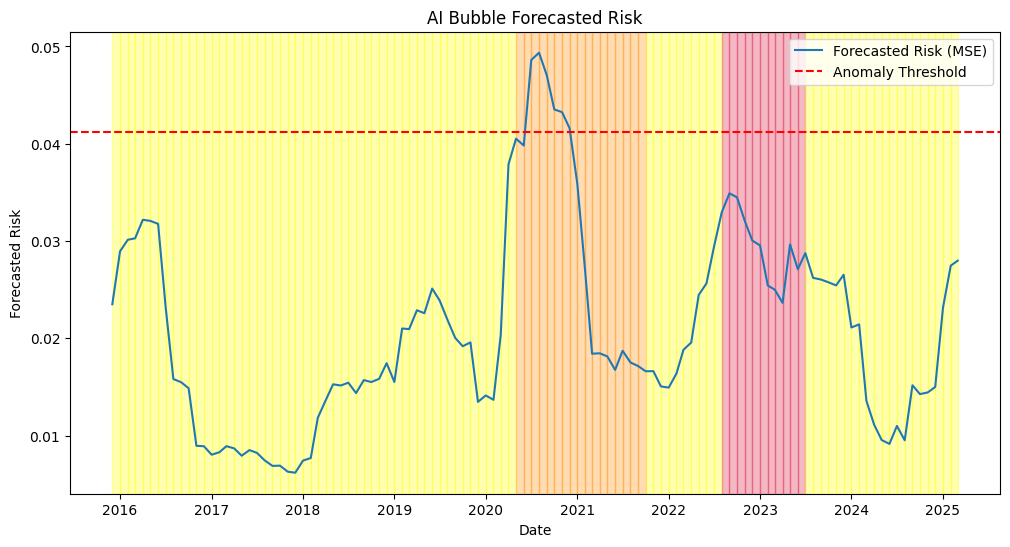

In [551]:
aicsv["Date"] = pd.to_datetime(aicsv["Date"])
ai_dates = aicsv["Date"].iloc[10:].reset_index(drop=True)  

phaseColors = {0: "yellow" , 1: "darkorange", 2: "crimson"}

ai_phasesdf["Date"] = pd.to_datetime(ai_phasesdf["Date"])
allAI = pd.DataFrame({
    "Date" : ai_dates,
    "mse" : AImse
}).merge(ai_phasesdf, on = "Date", how = "left")

plt.figure(figsize=(12, 6))
plt.plot(allAI["Date"], allAI["mse"], label="Forecasted Risk (MSE)")
plt.axhline(np.mean(AImse) + 2 * np.std(AImse), color="red", linestyle="--", label="Anomaly Threshold")

for i in range(len(allAI) - 1):
    start = allAI["Date"].iloc[i]
    end =allAI["Date"].iloc[i+1]
    phase = allAI["Predicted Phase"].iloc[i]
    color = phaseColors.get(phase, "#eeeeee") 
    plt.axvspan(start, end, color=color, alpha=0.3)


plt.legend()
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xlabel("Date")
plt.ylabel("Forecasted Risk")
plt.title("AI Bubble Forecasted Risk")
plt.legend()
plt.show()

In [132]:
# #This is when the MSE crossed the anomaly boundary

# threshold = np.mean(mse) + 2 * np.std(mse)
# cross = np.argmax(mse > threshold)

# firstCross = aicsv["Date"].iloc[steps + cross]
# print(firstCross)

2022-07-01 00:00:00


In [133]:
# #ARIMA forecasting

# aicsv["Date"] = pd.to_datetime(aicsv["Date"])

# riskdf = pd.DataFrame({"Date": aicsv["Date"].iloc[10:].reset_index(drop = True),
# "Risk Score" : mse})

# riskdf["Date"] = pd.to_datetime(riskdf["Date"])
# riskdf.set_index("Date", inplace = True)

# riskdf = riskdf.sort_index()

# modelARIMA = ARIMA(riskdf["Risk Score"], order = (2, 1, 1))  #WE chose the p,d,q values from testing with AIC with variation in mind
# fitMA = modelARIMA.fit()

# future = 24
# forecastMA = fitMA.forecast(steps = future)

# futureTime = pd.date_range(start = riskdf.index[-1] + pd.DateOffset(months = 1), periods= future, freq = "MS")
# forecastdf = pd.DataFrame({"Forecast Risk" : forecastMA.values}, index = futureTime)

# threshold = riskdf["Risk Score"].mean() + 2 * riskdf["Risk Score"].std()

# riskyTime = forecastdf[forecastdf["Forecast Risk"] > threshold]

# if not riskyTime.empty:
#     print("There is risk")
# else:
#     print("There is no risk")


There is risk


/Users/aksheythac/Desktop/Prof. Bennett Lab Work/Social Network Analysis/Social Networks/China AI Social Network - AUTHORS/.conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/aksheythac/Desktop/Prof. Bennett Lab Work/Social Network Analysis/Social Networks/China AI Social Network - AUTHORS/.conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/aksheythac/Desktop/Prof. Bennett Lab Work/Social Network Analysis/Social Networks/China AI Social Network - AUTHORS/.conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/aksheythac/Desktop/Prof. Be

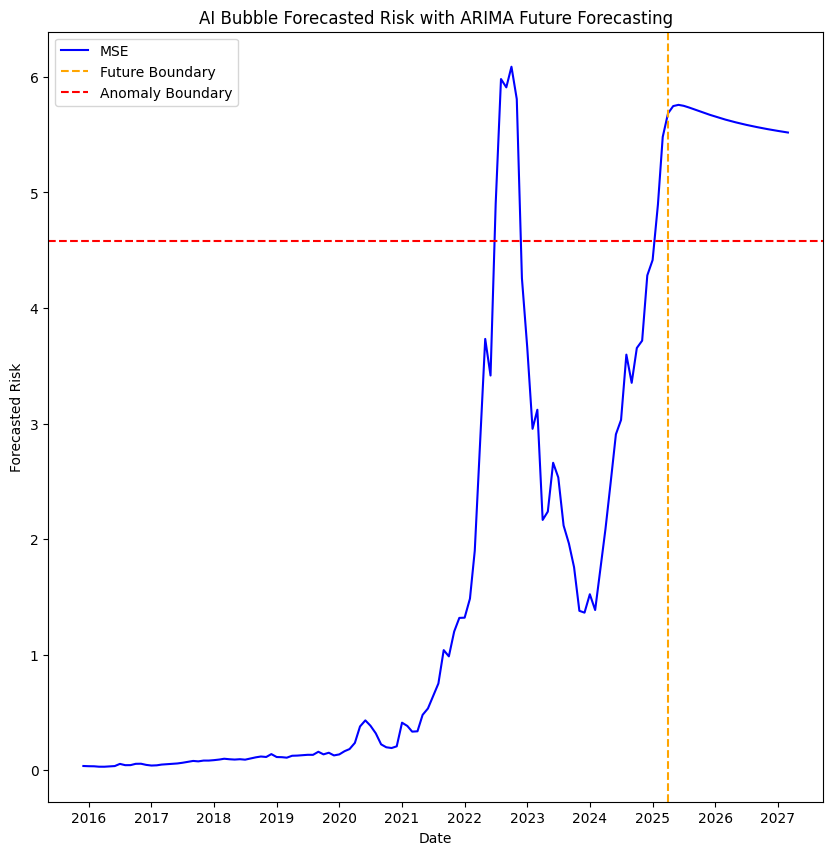

In [134]:
# allValues = pd.concat([riskdf["Risk Score"], forecastdf["Forecast Risk"]])
# allValues.index.name = "Date"

# plt.figure(figsize = (10, 10))

# plt.plot(allValues.index, allValues.values, label = "MSE", color = "blue")
# plt.axvline(forecastdf.index[0], color = "orange", linestyle = "--", label = "Future Boundary")
# plt.axhline(threshold, color = "red", linestyle = "--", label = "Anomaly Boundary")

# plt.gca().xaxis.set_major_locator(mdates.YearLocator())          
# plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  

# plt.xlabel("Date")
# plt.ylabel("Forecasted Risk")
# plt.title("AI Bubble Forecasted Risk with ARIMA Future Forecasting")
# plt.legend()
# plt.show()

In [ ]:
# #The method used to pick p, d, q. Chose the smallest AIC score
# for p in range(0, 5):
#     for d in range(0,5):
#         for q in range(0, 5):
#             modelAM = ARIMA(riskdf["Risk Score"], order=(p,d,q))
#             result = modelAM.fit()
#             print(p,d, q, result.aic)

In [136]:
# print(riskdf)

            Risk Score
Date                  
2015-12-01    0.037587
2016-01-01    0.035765
2016-02-01    0.035087
2016-03-01    0.031497
2016-04-01    0.031325
...                ...
2024-11-01    3.717517
2024-12-01    4.282052
2025-01-01    4.415007
2025-02-01    4.894699
2025-03-01    5.480329

[112 rows x 1 columns]
